# Black-Scholes: Every Formula Explained

This notebook walks through every method in `src/pricing/black_scholes.py` — what the formula is, where it comes from, and what it means in practice.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm
from src.pricing.black_scholes import BlackScholes

---
## 0 — The inputs

| Symbol | Name | Example |
|--------|------|---------|
| `S` | Current spot price | 123.2 CHF |
| `K` | Strike price | 123.2 CHF |
| `T` | Time to maturity (years) | 0.5 = 6 months |
| `r` | Risk-free rate (continuous) | 0.03 = 3% |
| `sigma` | Implied volatility (annual) | 0.20 = 20% |
| `q` | Dividend yield (continuous) | 0.0 = no dividends |

We will use **Novartis** as a running example throughout.

In [2]:
bs = BlackScholes(S=123.2, K=123.2, T=0.5, r=0.03, sigma=0.20, q=0.0)
print("Inputs loaded. S =", bs.S, "  K =", bs.K, "  T =", bs.T)

Inputs loaded. S = 123.2   K = 123.2   T = 0.5


---
## 1 — d1 and d2: the heart of the model

Everything in Black-Scholes flows through two numbers: **d1** and **d2**.

$$d_1 = \frac{\ln(S/K) + (r - q + \frac{1}{2}\sigma^2)\,T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - \sigma\sqrt{T}$$

### What does d1 measure?

Break it into pieces:

- **`ln(S/K)`** — how far in or out of the money we are right now (in log-space).  
  If `S = K`, this is 0 (at-the-money).

- **`(r - q + 0.5σ²) * T`** — the expected drift of the log-price over time.  
  The `0.5σ²` is a correction from Itô's lemma (log-normal drift adjustment).

- **`σ√T`** — the total volatility over the life of the option (the denominator normalises d1 to a standard-normal scale).

### What does d2 measure?

d2 = d1 − σ√T.

**N(d2)** = risk-neutral probability that the option expires in-the-money.  
**N(d1)** = delta of the call (the hedge ratio).

In [3]:
d1 = bs.d1()
d2 = bs.d2()

print(f"d1 = {d1:.4f}")
print(f"d2 = {d2:.4f}")
print()
print(f"N(d1)  = {norm.cdf(d1):.4f}  ← call delta")
print(f"N(d2)  = {norm.cdf(d2):.4f}  ← risk-neutral prob of finishing ITM")
print(f"N(-d2) = {norm.cdf(-d2):.4f}  ← risk-neutral prob of put finishing ITM")

d1 = 0.1768
d2 = 0.0354

N(d1)  = 0.5702  ← call delta
N(d2)  = 0.5141  ← risk-neutral prob of finishing ITM
N(-d2) = 0.4859  ← risk-neutral prob of put finishing ITM


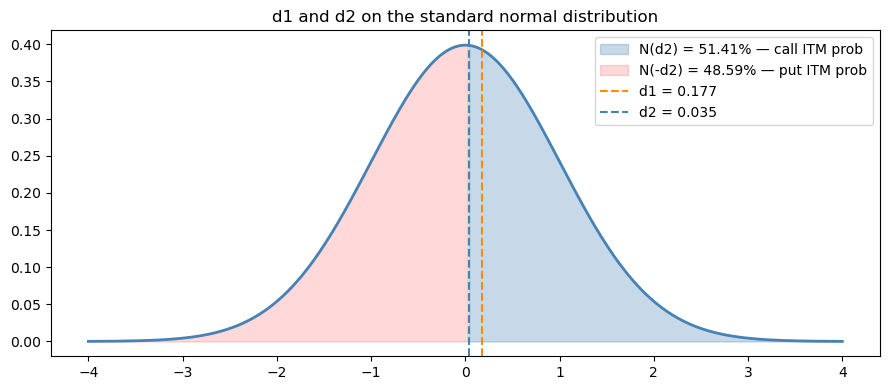

In [4]:
# Visualise N(d2) on the normal distribution
x = np.linspace(-4, 4, 500)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, norm.pdf(x), color="steelblue", lw=2)
ax.fill_between(x, norm.pdf(x), where=(x >= d2), alpha=0.3, color="steelblue", label=f"N(d2) = {norm.cdf(d2):.2%} — call ITM prob")
ax.fill_between(x, norm.pdf(x), where=(x <= d2), alpha=0.15, color="red", label=f"N(-d2) = {norm.cdf(-d2):.2%} — put ITM prob")
ax.axvline(d1, color="darkorange", lw=1.5, ls="--", label=f"d1 = {d1:.3f}")
ax.axvline(d2, color="steelblue", lw=1.5, ls="--", label=f"d2 = {d2:.3f}")
ax.set_title("d1 and d2 on the standard normal distribution")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2 — Call price

$$C = S\,e^{-qT}\,N(d_1) \;-\; K\,e^{-rT}\,N(d_2)$$

Read this as two parts:

| Term | Meaning |
|------|---------|
| $S\,e^{-qT}\,N(d_1)$ | Expected value of **receiving the stock** if the option expires ITM, discounted for dividends |
| $K\,e^{-rT}\,N(d_2)$ | PV of **paying the strike** — you only pay K if option is ITM, probability = N(d2) |

**Call = what you get (stock) − what you pay (strike), probability-weighted and discounted.**

In [ ]:
receive_stock = bs.S * np.exp(-bs.q * bs.T) * norm.cdf(d1)
pay_strike    = bs.K * np.exp(-bs.r * bs.T) * norm.cdf(d2)

print(f"Receive stock leg : {receive_stock:.4f}")
print(f"Pay strike leg    : {pay_strike:.4f}")
print(f"Call price        : {bs.call():.4f}")

---
## 3 — Put price

$$P = K\,e^{-rT}\,N(-d_2) \;-\; S\,e^{-qT}\,N(-d_1)$$

Mirror image of the call:

| Term | Meaning |
|------|---------|
| $K\,e^{-rT}\,N(-d_2)$ | PV of receiving the strike — you receive K only if put is ITM (S < K) |
| $S\,e^{-qT}\,N(-d_1)$ | Expected value of delivering the stock when put is ITM |

**Put = what you receive (strike) − what you deliver (stock), probability-weighted.**

> For reverse convertibles: the investor is **short a put**. So a higher put value = worse for the investor.

In [ ]:
receive_strike = bs.K * np.exp(-bs.r * bs.T) * norm.cdf(-d2)
deliver_stock  = bs.S * np.exp(-bs.q * bs.T) * norm.cdf(-d1)

print(f"Receive strike leg : {receive_strike:.4f}")
print(f"Deliver stock leg  : {deliver_stock:.4f}")
print(f"Put price          : {bs.put():.4f}")

---
## 4 — Put-Call Parity

$$C - P = S\,e^{-qT} - K\,e^{-rT}$$

This is a no-arbitrage relationship. It must hold exactly in Black-Scholes. It says:

> Owning a call and selling a put (same K, T) is equivalent to owning the forward on the stock.

We use it as a **sanity check** — the result should be exactly 0.

In [ ]:
error = bs.put_call_parity_check()
print(f"C - P = {bs.call():.6f}")
print(f"S·e⁻ᵍᵀ - K·e⁻ʳᵀ = {bs.S * np.exp(-bs.q * bs.T) - bs.K * np.exp(-bs.r * bs.T):.6f}")
print(f"Parity error = {error:.2e}  ({'OK' if abs(error) < 1e-10 else 'ERROR'})")

---
## 5 — Greeks

Greeks measure sensitivity of the option price to each input. They tell you **how much the price changes** when one input moves.

---
### 5a — Delta (δ)

$$\Delta_{call} = e^{-qT}\,N(d_1) \qquad \Delta_{put} = e^{-qT}\,(N(d_1) - 1)$$

**Delta = how much the option price moves per +1 unit move in spot.**

- Call delta: always between 0 and 1. ATM call ≈ 0.5
- Put delta: always between -1 and 0. ATM put ≈ -0.5
- Delta is also the **hedge ratio**: to delta-hedge a short put, you sell `|delta|` shares

For RC investors: **negative delta** (short put). If stock goes up, your position improves.

In [ ]:
print(f"Call delta : {bs.delta('call'):.4f}  → option gains {bs.delta('call'):.4f} per +1 CHF in spot")
print(f"Put delta  : {bs.delta('put'):.4f}  → option loses {abs(bs.delta('put')):.4f} per +1 CHF in spot")
print()

# Show how delta evolves with spot
spots = np.linspace(70, 180, 300)
call_deltas = [BlackScholes(s, bs.K, bs.T, bs.r, bs.sigma).delta('call') for s in spots]
put_deltas  = [BlackScholes(s, bs.K, bs.T, bs.r, bs.sigma).delta('put')  for s in spots]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(spots, call_deltas, label="Call delta", color="steelblue", lw=2)
ax.plot(spots, put_deltas,  label="Put delta",  color="darkorange", lw=2)
ax.axvline(bs.K, color="red", lw=1, ls=":", label=f"Strike = {bs.K}")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Spot")
ax.set_ylabel("Delta")
ax.set_title("Delta vs Spot — ATM delta ≈ ±0.5")
ax.legend()
plt.tight_layout()
plt.show()

---
### 5b — Gamma (Γ)

$$\Gamma = \frac{e^{-qT}\,N'(d_1)}{S\,\sigma\,\sqrt{T}}$$

where $N'(d_1) = \frac{1}{\sqrt{2\pi}}e^{-d_1^2/2}$ is the standard normal **PDF** (not CDF).

**Gamma = rate of change of delta. How fast your hedge ratio changes as spot moves.**

- Gamma is the same for call and put (put-call parity)
- Gamma is highest **at-the-money** and close to expiry
- High gamma = delta moves fast = you need to rebalance your hedge frequently
- For an RC investor (short put): **short gamma** — you lose when the stock moves a lot in either direction

In [ ]:
print(f"Gamma : {bs.gamma():.6f}")
print(f"Meaning: if spot moves +1, delta changes by {bs.gamma():.6f}")
print()

# Gamma is highest ATM
gammas = [BlackScholes(s, bs.K, bs.T, bs.r, bs.sigma).gamma() for s in spots]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(spots, gammas, color="steelblue", lw=2)
ax.axvline(bs.K, color="red", lw=1, ls=":", label=f"Strike = {bs.K}")
ax.set_xlabel("Spot")
ax.set_ylabel("Gamma")
ax.set_title("Gamma peaks at-the-money — delta changes fastest here")
ax.legend()
plt.tight_layout()
plt.show()

---
### 5c — Vega (ν)

$$\nu = S\,e^{-qT}\,N'(d_1)\,\sqrt{T} \times 0.01$$

The `× 0.01` means our vega is expressed **per 1% move in implied vol** (e.g., vol goes from 20% to 21%).

**Vega = how much the option price changes when implied vol rises by 1%.**

- Vega is the same for call and put
- Vega is always positive for long options (higher vol = more valuable)
- For an RC investor (short put): **short vega** — if vol spikes (e.g., market panic), your position loses value
- Vega is largest ATM and for long-dated options

In [ ]:
print(f"Vega : {bs.vega():.4f}  per 1% vol move")
print(f"If vol goes from 20% → 21%, put price changes by ~{bs.vega():.4f}")
print()

# Vega vs vol
vols = np.linspace(0.05, 0.60, 200)
vegas = [BlackScholes(bs.S, bs.K, bs.T, bs.r, v).vega() for v in vols]

# Vega vs time to maturity
times = np.linspace(0.05, 2.0, 200)
vegas_T = [BlackScholes(bs.S, bs.K, t, bs.r, bs.sigma).vega() for t in times]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(vols * 100, vegas, color="steelblue", lw=2)
ax1.set_xlabel("Implied Vol (%)")
ax1.set_ylabel("Vega per 1% vol move")
ax1.set_title("Vega vs Volatility")

ax2.plot(times * 12, vegas_T, color="darkorange", lw=2)
ax2.set_xlabel("Time to Maturity (months)")
ax2.set_ylabel("Vega per 1% vol move")
ax2.set_title("Vega vs Time — longer options are more vol-sensitive")

plt.tight_layout()
plt.show()

---
### 5d — Theta (Θ)

$$\Theta_{call} = \frac{1}{365}\left[ -\frac{S\,e^{-qT}\,N'(d_1)\,\sigma}{2\sqrt{T}} - r K e^{-rT} N(d_2) + q S e^{-qT} N(d_1) \right]$$

The `÷ 365` converts from per-year to **per calendar day**.

**Theta = how much the option loses (or gains) in value as one day passes, all else equal.**

- Theta is almost always **negative** for long options — time decay hurts option buyers
- For an RC investor (short put): **positive theta** — every day that passes without a crash is good
- Three terms in the formula:
  1. `−S·N'(d1)·σ / (2√T)` — the main time-decay term (always negative)
  2. `−r·K·e⁻ʳᵀ·N(d2)` — interest rate effect on the deferred strike payment
  3. `+q·S·e⁻ᵠᵀ·N(d1)` — dividend effect (dividends reduce the call, help the put)

In [ ]:
print(f"Call theta : {bs.theta('call'):.4f} per day")
print(f"Put theta  : {bs.theta('put'):.4f} per day")
print(f"  → put loses {abs(bs.theta('put')):.4f} in value each passing day (long put perspective)")
print(f"  → short put GAINS {abs(bs.theta('put')):.4f} per day — this is the RC investor")
print()

# Theta accelerates near expiry
times_close = np.linspace(0.01, 1.0, 300)
thetas_put = [BlackScholes(bs.S, bs.K, t, bs.r, bs.sigma).theta('put') for t in times_close]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(times_close * 365, thetas_put, color="darkorange", lw=2)
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Days to maturity")
ax.set_ylabel("Put theta (per day)")
ax.set_title("Theta accelerates near expiry — time decay is fastest in the last weeks")
plt.tight_layout()
plt.show()

---
### 5e — Rho (ρ)

$$\rho_{call} = K\,T\,e^{-rT}\,N(d_2) \times 0.01$$
$$\rho_{put}  = -K\,T\,e^{-rT}\,N(-d_2) \times 0.01$$

The `× 0.01` expresses rho **per 1% move in rates** (e.g., 3% → 4%).

**Rho = how much the option price changes when interest rates rise by 1%.**

- Calls have positive rho — higher rates make calls more valuable (holding stock costs more, so the call is a cheaper substitute)
- Puts have negative rho — higher rates reduce put values (PV of receiving the strike is lower)
- Rho is usually the least important Greek for short-dated options

In [ ]:
print(f"Call rho : {bs.rho('call'):.4f}  per 1% rate rise")
print(f"Put rho  : {bs.rho('put'):.4f}  per 1% rate rise")

---
## 6 — Implied Volatility (Newton-Raphson)

The reverse question: given a **market price**, what volatility does it imply?

Black-Scholes has no closed-form inverse for sigma, so we solve numerically using **Newton-Raphson**:

$$\sigma_{n+1} = \sigma_n - \frac{BS(\sigma_n) - P_{market}}{\nu(\sigma_n)}$$

At each step:
1. Price the option with current `sigma` guess
2. Compute the error vs market price
3. Divide by vega — this tells us how much sigma needs to change to fix the error
4. Update sigma and repeat until convergence

**Why vega in the denominator?** Because vega = dPrice/dSigma. Newton-Raphson uses the derivative of the function you're solving.

In [ ]:
# Suppose the market put price is 8.50 — what vol does that imply?
market_put_price = 8.50

iv = bs.implied_vol(market_price=market_put_price, option="put")
print(f"Market put price : {market_put_price}")
print(f"Implied vol      : {iv:.4f} = {iv*100:.2f}%")
print()

# Verify: re-price with the implied vol
verify = BlackScholes(bs.S, bs.K, bs.T, bs.r, iv)
print(f"Back-check: BS put with IV = {verify.put():.4f}  (should be {market_put_price})")

In [ ]:
# Show Newton-Raphson convergence step by step
sigma = 0.20  # initial guess
print(f"{'Step':>4}  {'Sigma':>8}  {'BS Price':>10}  {'Error':>10}  {'Vega':>8}  {'Step size':>10}")
print("-" * 60)

for i in range(8):
    trial = BlackScholes(bs.S, bs.K, bs.T, bs.r, sigma)
    price = trial.put()
    vega  = trial.vega() * 100
    error = price - market_put_price
    step  = error / vega
    print(f"{i:>4}  {sigma:>8.5f}  {price:>10.5f}  {error:>10.6f}  {vega:>8.4f}  {step:>10.6f}")
    if abs(error) < 1e-6:
        print("Converged!")
        break
    sigma -= step

---
## 7 — Greeks summary table

All Greeks for our Novartis example:

In [ ]:
print(f"{'Greek':<12} {'Call':>10} {'Put':>10}  Interpretation")
print("-" * 70)
print(f"{'Price':<12} {bs.call():>10.4f} {bs.put():>10.4f}")
print(f"{'Delta':<12} {bs.delta('call'):>10.4f} {bs.delta('put'):>10.4f}  per +1 CHF in spot")
print(f"{'Gamma':<12} {bs.gamma():>10.6f} {bs.gamma():>10.6f}  per +1 CHF in spot (delta change)")
print(f"{'Vega':<12} {bs.vega():>10.4f} {bs.vega():>10.4f}  per +1% implied vol")
print(f"{'Theta':<12} {bs.theta('call'):>10.4f} {bs.theta('put'):>10.4f}  per calendar day")
print(f"{'Rho':<12} {bs.rho('call'):>10.4f} {bs.rho('put'):>10.4f}  per +1% interest rate")

---
## 8 — What this means for Reverse Convertibles

An RC investor is **short a put**. So all the signs flip:

| Greek | Long put | Short put (RC investor) | Implication |
|-------|----------|--------------------------|-------------|
| Delta | Negative | **Positive** | You benefit when stock rises |
| Gamma | Positive | **Negative** | You lose if stock makes big moves |
| Vega  | Positive | **Negative** | A vol spike (market crash fear) hurts you |
| Theta | Negative | **Positive** | Every passing day is money in your pocket |
| Rho   | Negative | **Positive** | Higher rates benefit you slightly |

**The coupon you receive on the RC is compensation for being short these risks.**

Next step → `src/pricing/rc_pricer.py`: use `BlackScholes.put()` to price a full RC.